# 05 — Output Generation
**Prior Authorization Automation | Healthcare NLP Portfolio**

The purpose of this notebook is to format  the LLM classification results into the three deliverables the pipeline produces:

1. **PA justification letter** — professional, payer-compliant clinical language
2. **Decision summary** — structured output with confidence score and routing
3. **Documentation gap report** — what is missing and what would be needed for approval

In [1]:
# Environment Setup (works in Google Colab AND local Jupyter)
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import drive
  drive.mount('/content/drive')
  BASE = '/content/drive/MyDrive/PortfolioProjects/PriorAuthAutomation/data'
else:
  BASE = '..'

os.chdir(BASE)
print(f'Environment: {"Google Colab" if IN_COLAB else "Local Jupyter"}')
print(f'Working Directory: {os.getcwd()}')

Mounted at /content/drive
Environment: Google Colab
Working Directory: /content/drive/MyDrive/PortfolioProjects/PriorAuthAutomation/data


In [2]:
#Common Imports
import json
import os
import warnings
from datetime import date
from typing import List, Dict

import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

with open('../data/classified_cases.json', 'r') as f:
    classified_cases = json.load(f)

print(f'Loaded {len(classified_cases)} classified cases')

Loaded 25 classified cases


## PA Letter Generation

This portion of the notebook formats the LLM rationale into a structured determination letter.

Language is calibrated to mirror real payer determination notices — clinical specificity, appeal rights language, and authorization details.

In [3]:
def generate_pa_letter(case: dict) -> str:
    """
    Generate a structured PA determination letter from LLM output.
    Mirrors the format of real payer determination notices.
    """
    llm      = case.get('llm_result', {})
    ext      = case.get('predicted_extraction', {})
    decision = llm.get('decision', 'PENDING_REVIEW')
    today    = date.today().strftime('%B %d, %Y')
    ref_num  = f'AUTH-{case["case_id"]}-{date.today().strftime("%Y%m%d")}'

    icd_str  = ', '.join(ext.get('diagnoses', [])) or 'See clinical note'
    cpt_str  = ', '.join(ext.get('procedures', [])) or 'See clinical note'
    gaps     = llm.get('documentation_gaps', [])
    rationale = llm.get('clinical_rationale', '')
    criteria  = llm.get('payer_criteria_cited', 'Standard medical necessity criteria')

    header_map = {
        'APPROVE':        'PRIOR AUTHORIZATION — APPROVED',
        'DENY':           'PRIOR AUTHORIZATION — DENIED',
        'PENDING_REVIEW': 'PRIOR AUTHORIZATION — UNDER CLINICAL REVIEW'
    }

    if decision == 'APPROVE':
        body = f"""We are pleased to inform you that the requested service has been approved
based on our review of the submitted clinical documentation.

Authorization Number: {ref_num}
Valid Period:         {today} — 90 days from date of issue
Diagnosis Codes:      {icd_str}
Procedure Codes:      {cpt_str}
Policy Reference:     {criteria}

CLINICAL BASIS FOR APPROVAL:
{rationale}"""

    elif decision == 'DENY':
        gap_text = '\n'.join(f'  • {g}' for g in gaps) if gaps else '  • See clinical policy for requirements'
        body = f"""Following review of the submitted clinical information, we are unable to
approve the requested service at this time.

Reason for Denial:    {llm.get('denial_reason', 'Does not meet medical necessity criteria')}
Diagnosis Codes:      {icd_str}
Procedure Codes:      {cpt_str}
Policy Reference:     {criteria}

CLINICAL BASIS FOR DENIAL:
{rationale}

DOCUMENTATION REQUIRED FOR RECONSIDERATION:
{gap_text}

APPEAL RIGHTS:
You have the right to appeal this decision within 60 calendar days of this notice.
To request a peer-to-peer review with our Medical Director, contact Medical Management
within 14 business days. To submit an appeal, include updated clinical documentation
addressing the items listed above."""

    else:  # PENDING_REVIEW
        body = f"""Your prior authorization request is currently under clinical review
by our medical management team.

Reference Number:     {ref_num}
Expected Resolution:  Within 3 business days (standard) or 72 hours (urgent)
Diagnosis Codes:      {icd_str}

REASON FOR REVIEW:
{rationale}

If this request is clinically urgent, please contact our Clinical Review team
directly and reference the number above."""

    return f"""{"="*65}
{header_map[decision]}
{"="*65}

Date:             {today}
Case Reference:   {case['case_id']}
Health Plan:      {case['insurance_type']}
Clinical Category:{case['clinical_category']}

{body}

{"-"*65}
Recommended Action: {llm.get('recommended_action', '')}
AI Confidence:      {llm.get('confidence', 0):.0%}
                    (Cases below 70% confidence are routed to human review)

IMPORTANT: This determination was generated with AI assistance and is subject
to clinical oversight review per organizational policy. All denials require
human clinical reviewer sign-off before issuance.
{"="*65}
"""


print('Letter generator defined')

Letter generator defined


## Sample Letters - One Per Decision Type

In [4]:
# Print one example of each decision type
shown = set()
for case in classified_cases:
    decision = case.get('llm_result', {}).get('decision', '')
    if decision not in shown:
        print(generate_pa_letter(case))
        shown.add(decision)
    if len(shown) == 3:
        break

PRIOR AUTHORIZATION — APPROVED

Date:             April 20, 2026
Case Reference:   PA-001
Health Plan:      Aetna HMO
Clinical Category:biologic_dermatology

We are pleased to inform you that the requested service has been approved
based on our review of the submitted clinical documentation.

Authorization Number: AUTH-PA-001-20260420
Valid Period:         April 20, 2026 — 90 days from date of issue
Diagnosis Codes:      L20.9
Procedure Codes:      See clinical note
Policy Reference:     Aetna Clinical Policy Bulletin — Dupilumab (Dupixent)

CLINICAL BASIS FOR APPROVAL:
Clinical documentation supports medical necessity per payer criteria. Step therapy requirements are satisfied with documented prior treatment failures. Specialist evaluation supports the requested treatment plan.

-----------------------------------------------------------------
Recommended Action: Issue authorization. Notify provider and member.
AI Confidence:      93%
                    (Cases below 70% confidence ar

## Documentation Gap Report

In [5]:
def generate_gap_report(cases: list) -> pd.DataFrame:
    """
    Aggregate documentation gaps across all cases.
    Useful for identifying systemic documentation issues at a provider level.
    """
    rows = []
    for case in cases:
        llm  = case.get('llm_result', {})
        gaps = llm.get('documentation_gaps', [])
        rows.append({
            'case_id':           case['case_id'],
            'decision':          llm.get('decision', ''),
            'true_label':        case['true_label'],
            'clinical_category': case['clinical_category'],
            'doc_quality':       case['documentation_quality'],
            'n_gaps':            len(gaps),
            'gaps':              '; '.join(gaps) if gaps else 'None',
            'confidence':        llm.get('confidence', 0),
        })
    return pd.DataFrame(rows)


df_gaps = generate_gap_report(classified_cases)

print('=== DOCUMENTATION GAP REPORT ===')
print(f'Cases with no gaps:      {(df_gaps.n_gaps == 0).sum()}')
print(f'Cases with 1-2 gaps:     {((df_gaps.n_gaps >= 1) & (df_gaps.n_gaps <= 2)).sum()}')
print(f'Cases with 3+ gaps:      {(df_gaps.n_gaps >= 3).sum()}')
print()
print('Gap count by decision:')
print(df_gaps.groupby('decision')['n_gaps'].mean().round(2).to_string())
print()
print('Cases needing documentation before resubmission:')
deny_gaps = df_gaps[df_gaps.decision == 'DENY'][['case_id','clinical_category','gaps']]
print(deny_gaps.to_string(index=False))

=== DOCUMENTATION GAP REPORT ===
Cases with no gaps:      23
Cases with 1-2 gaps:     1
Cases with 3+ gaps:      1

Gap count by decision:
decision
APPROVE           0.0
DENY              2.5
PENDING_REVIEW    0.0

Cases needing documentation before resubmission:
case_id    clinical_category                                                                     gaps
 PA-005      genetic_testing                            does not meet criteria; no genetic counseling
 PA-008 biologic_pulmonology no prior therapy documented; missing lab values; eosinophil count absent


## Decision Summary Dashboard

In [6]:
def generate_decision_summary(cases: list) -> pd.DataFrame:
    """Flat decision summary table for all cases."""
    rows = []
    for case in cases:
        llm = case.get('llm_result', {})
        rows.append({
            'Case ID':      case['case_id'],
            'Category':     case['clinical_category'],
            'Insurance':    case['insurance_type'].split('(')[0].strip(),
            'Decision':     llm.get('decision', ''),
            'True Label':   case['true_label'],
            'Match':        'YES' if llm.get('decision') == case['true_label'] else 'NO',
            'Confidence':   f"{llm.get('confidence', 0):.0%}",
            'Doc Quality':  case['documentation_quality'],
            'Gaps':         len(llm.get('documentation_gaps', [])),
            'Next Action':  llm.get('recommended_action', '')[:50],
        })
    return pd.DataFrame(rows)


df_summary = generate_decision_summary(classified_cases)

pd.set_option('display.max_colwidth', 55)
pd.set_option('display.max_rows', 30)
print('=== DECISION SUMMARY ===')
print(df_summary[['Case ID','Category','Decision','True Label','Match','Confidence','Gaps']]
      .to_string(index=False))

=== DECISION SUMMARY ===
Case ID                  Category       Decision     True Label Match Confidence  Gaps
 PA-001      biologic_dermatology        APPROVE        APPROVE   YES        93%     0
 PA-002             glp1_diabetes        APPROVE        APPROVE   YES        93%     0
 PA-003                   imaging PENDING_REVIEW           DENY    NO        58%     0
 PA-004     biologic_rheumatology        APPROVE        APPROVE   YES        93%     0
 PA-005           genetic_testing           DENY           DENY   YES        72%     2
 PA-006             mental_health PENDING_REVIEW PENDING_REVIEW   YES        58%     0
 PA-007         bariatric_surgery PENDING_REVIEW        APPROVE    NO        58%     0
 PA-008      biologic_pulmonology           DENY           DENY   YES        69%     3
 PA-009                  oncology PENDING_REVIEW        APPROVE    NO        58%     0
 PA-010              glp1_obesity        APPROVE PENDING_REVIEW    NO        93%     0
 PA-011     biolog

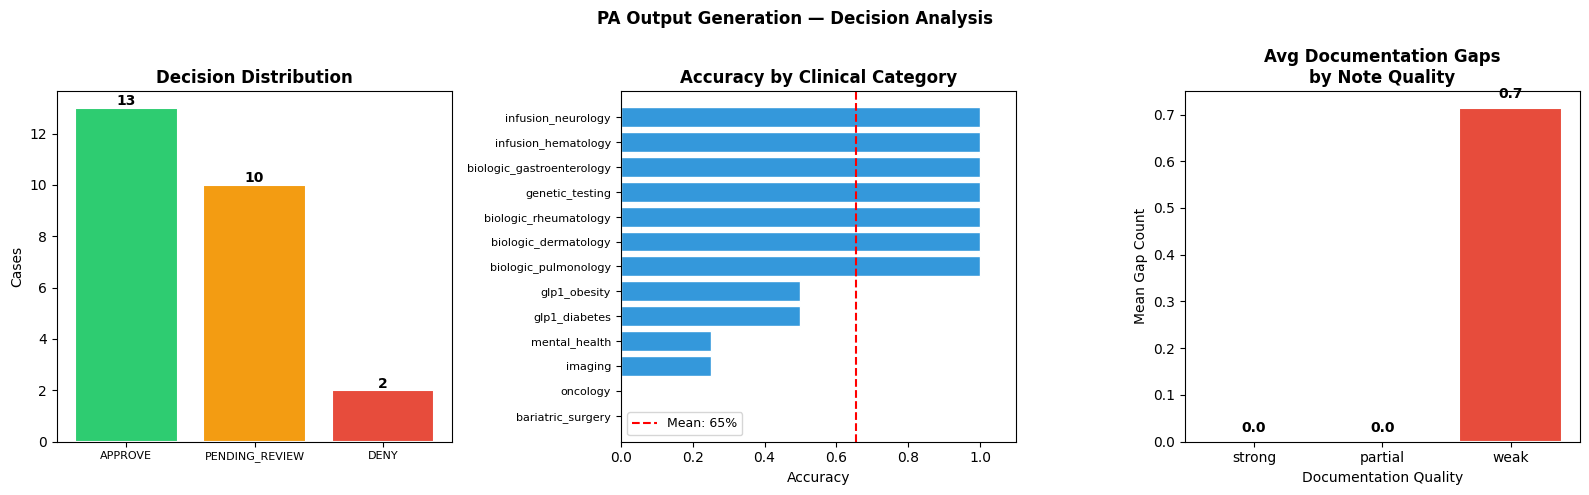

In [7]:
colors_map = {'APPROVE': '#2ecc71', 'DENY': '#e74c3c', 'PENDING_REVIEW': '#f39c12'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('PA Output Generation — Decision Analysis', fontweight='bold')

# Decision distribution
dec_counts = df_summary['Decision'].value_counts()
axes[0].bar(dec_counts.index, dec_counts.values,
            color=[colors_map.get(k, '#95a5a6') for k in dec_counts.index],
            edgecolor='white', linewidth=1.5)
for i, (idx, val) in enumerate(dec_counts.items()):
    axes[0].text(i, val + 0.1, str(val), ha='center', fontweight='bold')
axes[0].set_title('Decision Distribution', fontweight='bold')
axes[0].set_ylabel('Cases')
axes[0].tick_params(axis='x', labelsize=8)

# Accuracy by category
cat_acc = df_summary.groupby('Category').apply(
    lambda x: (x['Match'] == 'YES').mean()
).sort_values()
bars = axes[1].barh(range(len(cat_acc)), cat_acc.values,
                    color='#3498db', edgecolor='white', linewidth=1)
axes[1].set_yticks(range(len(cat_acc)))
axes[1].set_yticklabels([c[:25] for c in cat_acc.index], fontsize=8)
axes[1].axvline(x=cat_acc.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean: {cat_acc.mean():.0%}')
axes[1].set_title('Accuracy by Clinical Category', fontweight='bold')
axes[1].set_xlabel('Accuracy')
axes[1].set_xlim(0, 1.1)
axes[1].legend(fontsize=9)

# Gaps by doc quality
quality_gaps = df_summary.groupby('Doc Quality')['Gaps'].mean()
quality_gaps = quality_gaps.reindex(['strong','partial','weak'])
q_colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[2].bar(quality_gaps.index, quality_gaps.values,
            color=q_colors, edgecolor='white', linewidth=1.5)
for i, val in enumerate(quality_gaps.values):
    axes[2].text(i, val + 0.02, f'{val:.1f}', ha='center', fontweight='bold')
axes[2].set_title('Avg Documentation Gaps\nby Note Quality', fontweight='bold')
axes[2].set_ylabel('Mean Gap Count')
axes[2].set_xlabel('Documentation Quality')

plt.tight_layout()
os.makedirs('evaluation', exist_ok=True)
plt.savefig('evaluation/05_output_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Export All Outputs



In [8]:
# Generate all letters
all_letters = []
for case in classified_cases:
    all_letters.append({
        'case_id':        case['case_id'],
        'decision':       case.get('llm_result', {}).get('decision', ''),
        'true_label':     case['true_label'],
        'letter':         generate_pa_letter(case),
        'gold_standard':  case.get('gold_standard_letter', ''),
    })

# Save letters
with open('../data/generated_letters.json', 'w') as f:
    json.dump(all_letters, f, indent=2)

# Save decision summary CSV
df_summary.to_csv('evaluation/decision_summary.csv', index=False)

# Save gap report CSV
df_gaps.to_csv('evaluation/gap_report.csv', index=False)

print(f'Generated {len(all_letters)} letters → data/generated_letters.json')
print('Decision summary → evaluation/decision_summary.csv')
print('Gap report       → evaluation/gap_report.csv')

Generated 25 letters → data/generated_letters.json
Decision summary → evaluation/decision_summary.csv
Gap report       → evaluation/gap_report.csv


## KEY TAKEAWAYS

**THREE OUTPUT TYPES**
  - **PA Letter:** Professional determination notice with clinical rationale, authorization number, appeal rights language calibrated per decision type.

  - **Decision Summary:** Structured flat table — decision, confidence, accuracy flag, and next action per case.

  - **Gap Report:** Aggregated documentation gaps — useful for provider-level feedback and quality improvement.

---

**LETTER DESIGN**
  - **Appeal language:** All DENY letters include appeal rights and peer-to-peer review information — required by most state PA laws and CMS regulations.

  - **Human oversight:**  Disclaimer on every letter: AI-generated, subject to clinical review before issuance.

  - **Confidence gate:** Cases below 70% confidence automatically route to human reviewer — not auto-issued.

---

**PRODUCTION PATH**
  - **Template engine:** Replace f-string templates with Jinja2 for payer-specific letter formatting.

  - **FHIR output:** Structure decisions as FHIR ClaimResponse resources for EHR system integration.

Next: `06_evaluation_roi.ipynb`